# Tarea

## Parte 1

Descargar el archivo 'auto-mpg.data-original', disponible en https://archive.ics.uci.edu/dataset/9/auto+mpg.

Luego cárguelo en Pandas, póngale nombre a las columnas de acuerdo a lo indicado en el archivo 'auto-mpg.names', e identifique las cadenas que son datos nulos.

Indique cuántas variables y registros tiene el dataset, y que variables contienen datos nulos.

**Tip:** En este dataset las columnas estan separadas por tabuladores, no por comas, así que debe usar el parámetro sep='\s+'.

In [1]:
import pandas as pd

df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data-original", sep=r'\s+', header=None,
                 names=['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name'])
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0,chevrolet chevelle malibu
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0,buick skylark 320
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0,plymouth satellite
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0,amc rebel sst
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0,ford torino


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     406 non-null    float64
 2   displacement  406 non-null    float64
 3   horsepower    400 non-null    float64
 4   weight        406 non-null    float64
 5   acceleration  406 non-null    float64
 6   model_year    406 non-null    float64
 7   origin        406 non-null    float64
 8   car_name      406 non-null    object 
dtypes: float64(8), object(1)
memory usage: 28.7+ KB


In [4]:
df.duplicated().sum()

0

In [7]:
df[df.duplicated(subset=['car_name'])]['car_name'].value_counts()

car_name
ford pinto                           5
amc matador                          4
toyota corolla                       4
ford maverick                        4
amc gremlin                          3
peugeot 504                          3
amc hornet                           3
toyota corona                        3
chevrolet impala                     3
chevrolet chevette                   3
chevrolet caprice classic            2
volkswagen dasher                    2
dodge colt                           2
chevrolet nova                       2
honda civic                          2
pontiac catalina                     2
chevrolet citation                   2
ford gran torino                     2
ford galaxie 500                     2
chevrolet vega                       2
plymouth duster                      2
plymouth fury iii                    2
buick estate wagon (sw)              1
oldsmobile cutlass salon brougham    1
vw rabbit                            1
ford country squ

## Parte 2

Configure como índice la columna 'car_name'.

Elimine los registros que tengan datos nulos en la variable 'mpg' únicamente.

¿Cuántos registros quedan?

In [3]:
df.set_index('car_name', inplace=True)
df = df.dropna(subset=['mpg'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    float64
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    float64
 7   origin        398 non-null    float64
dtypes: float64(8)
memory usage: 28.0+ KB


## Parte 3

Impute la media de la variable 'horsepower' a los datos nulos de esta misma variable.

Presente las estadisticas descriptivas de todas las variables, considerando que la variable 'origin' es categórica.

Grafique los histogramas de las variables numéricas y diagramas de barras de las variables categóricas.

Analice las gráficas.

In [4]:
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())
df.drop(['origin'], axis=1).describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.199187,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,95.000000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [5]:
df['origin'].astype('object').describe()

count     398.0
unique      3.0
top         1.0
freq      249.0
Name: origin, dtype: float64

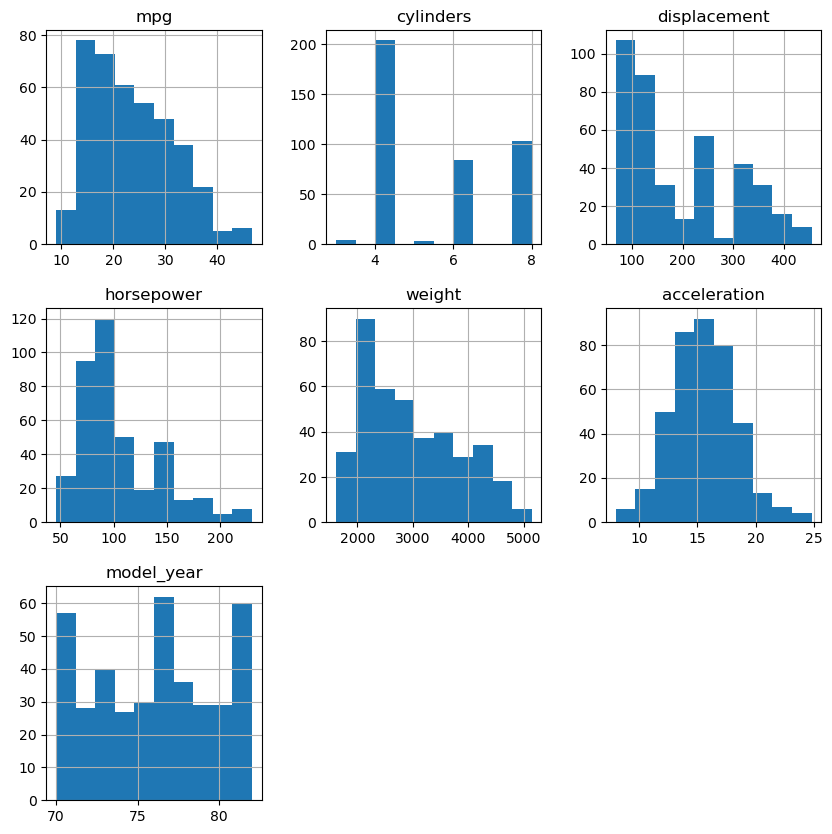

In [7]:
df.drop(['origin'], axis=1).hist(figsize=(10, 10));

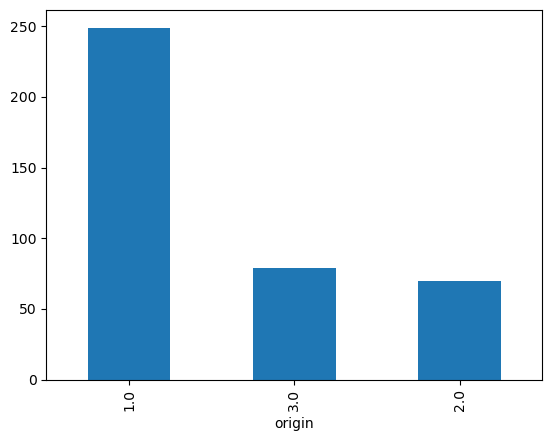

In [10]:
df['origin'].value_counts().plot(kind='bar');

## Parte 4

Considere que la variable a predecir es 'origin'. Haga gráficos de cajas de las otras variables separadas por las categorías de esta variable.

Indique qué observa en cada caso. ¿En qué variables se observan diferencias importantes entre categorías de **origin**?

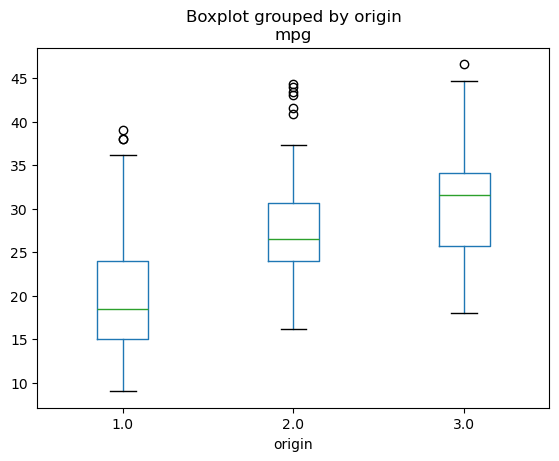

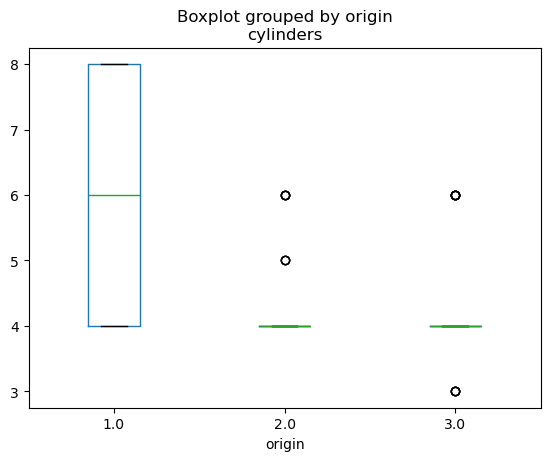

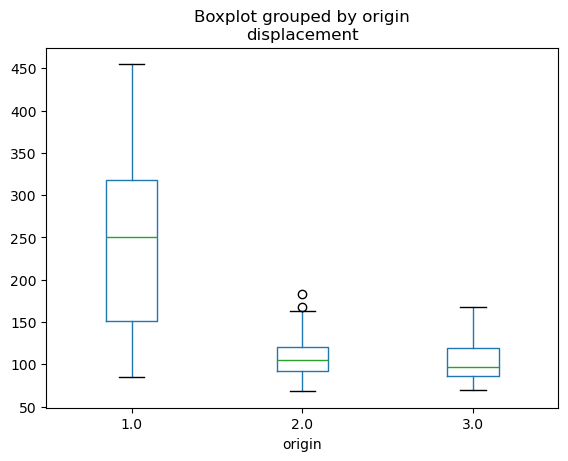

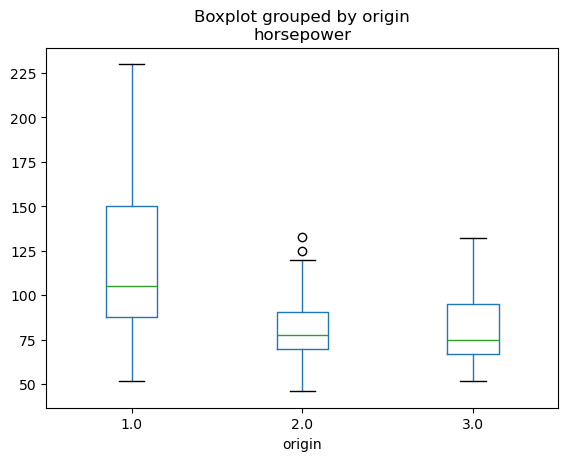

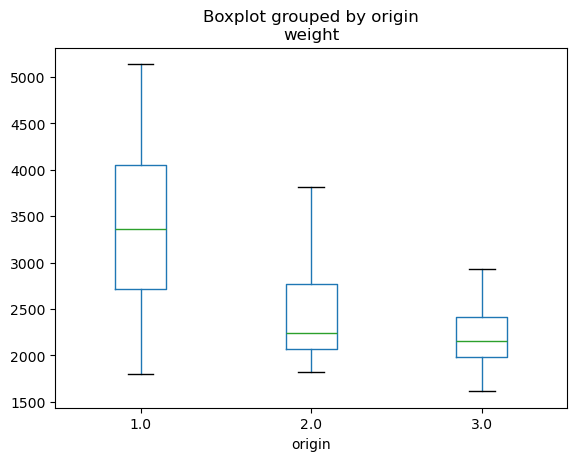

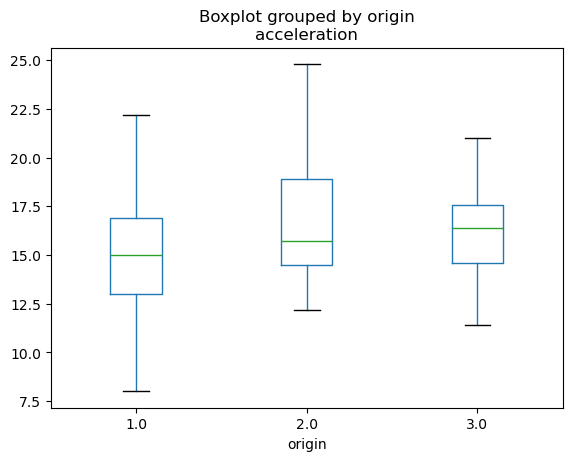

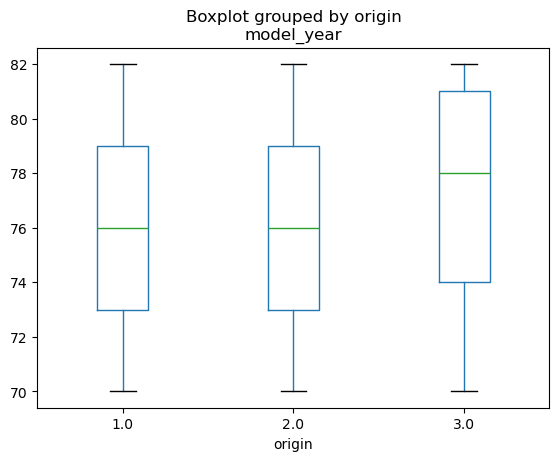

In [15]:
for var in df.drop(['origin'], axis=1).columns:
    df.boxplot(column=var, by='origin', grid=False);

## Parte 5

Considere que la variable a predecir es 'mpg'. Haga gráficos de dispersión de las otras variables numéricas versus esta variable.

Indique que observa en cada caso. ¿En qué casos se observa una relación clara entre las variables?

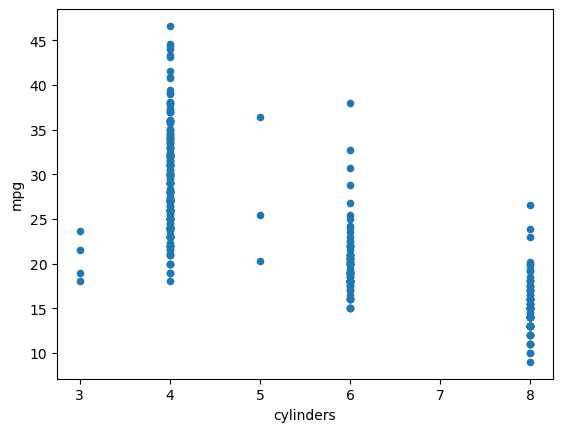

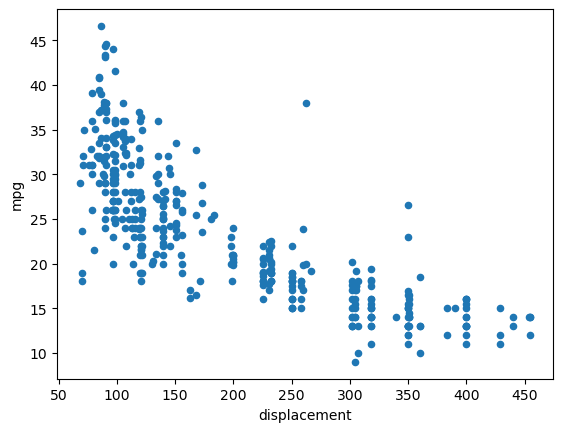

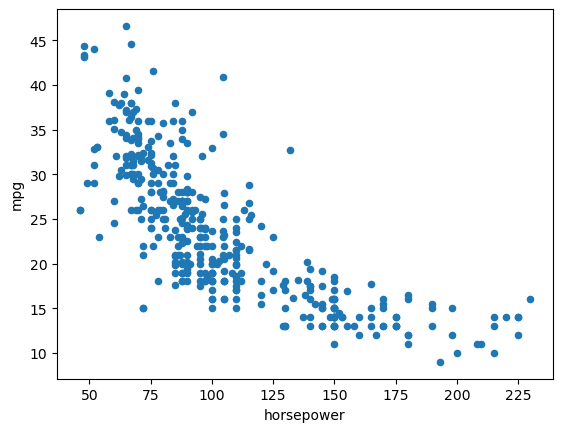

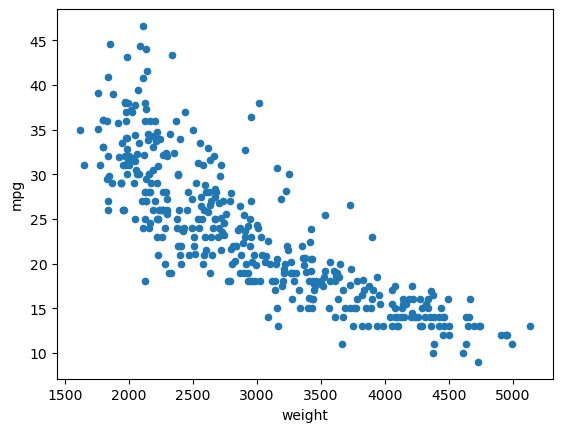

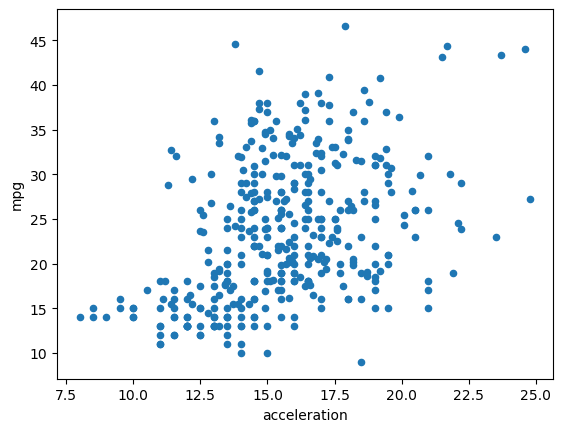

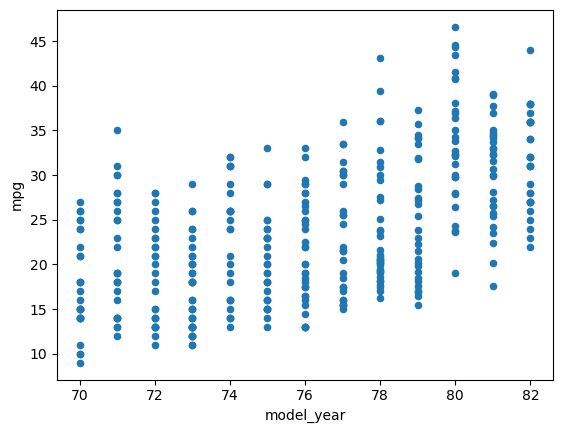

In [14]:
for var in df.drop(['origin', 'mpg'], axis=1).columns:
    df.plot.scatter(x=var, y='mpg');

## Parte 6

Suponga que va a usar el resultado de los análisis hechos en los puntos 4 y 5 para seleccionar 4 variables que usará para entrenar un modelo de aprendizaje de máquina que prediga la variable **mpg**. ¿Qué variables escogería? Justifique su respuesta.